# Logistic Regression Classification: Anime 'Hit' Analysis

This notebook provides a complete pipeline for exploring the MyAnimeList dataset and training a Logistic Regression classifier. It uses the refactored modular structure in the `src/` directory.

## 1. Data Loading & Exploration
We use the `src.data_loader` to fetch the dataset.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
import os
import sys

sys.path.append(os.getcwd())

from src.data_loader import load_data
from src.preprocessing import clean_data

df_raw = load_data()
df, _ = clean_data(df_raw)
df['target_name'] = df['target'].map({1: 'Hit', 0: 'Standard'})

print(f'Dataset Summary:')
print(df['target_name'].value_counts(normalize=True))

c:\Users\User\Downloads\ml assignment\ml-entertainment-rating-analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading dataset...
Dataset found locally. Loading from data folder...
Loaded 19311 records.
Cleaning data...
Dataset Summary:
target_name
Standard    0.93706
Hit         0.06294
Name: proportion, dtype: float64


### Visualizing Feature Distributions
We use violin plots to see how feature distributions differ between Hits and Standard releases.

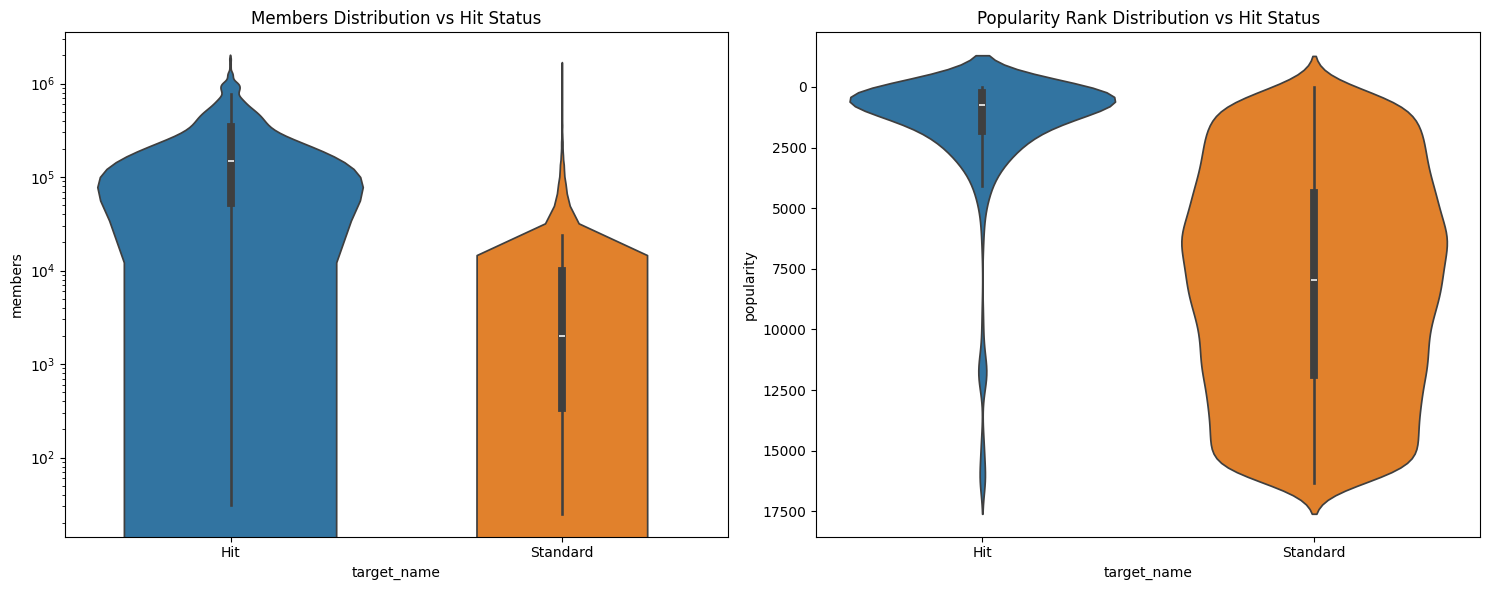

In [2]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.violinplot(x='target_name', y='members', data=df, hue='target_name', legend=False)
plt.title('Members Distribution vs Hit Status')
plt.yscale('log')
plt.subplot(1, 2, 2)
sns.violinplot(x='target_name', y='popularity', data=df, hue='target_name', legend=False)
plt.title('Popularity Rank Distribution vs Hit Status')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Multivariate Analysis
Checking the density of Hits using JointPlots.

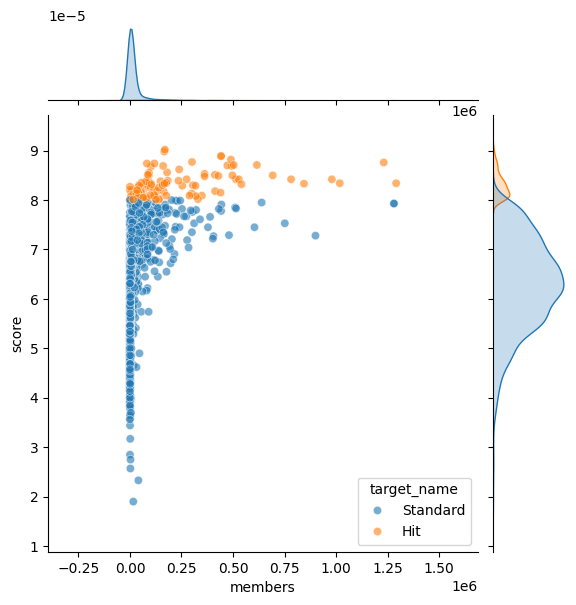

In [3]:
sns.jointplot(x='members', y='score', data=df.sample(2000), hue='target_name', alpha=0.6)
plt.show()

## 2. Model Training & Evaluation
Now we use the `src.preprocessing`, `src.train`, and `src.evaluate` modules to build the classification model.

In [4]:
from src.preprocessing import preprocess_training_data
from src.train import train_and_select_best
from src.evaluate import calculate_metrics, plot_comparison_curves, plot_confusion_matrix, plot_feature_importance

# 1. Preprocess
X_train, X_test, y_train, y_test, feature_names = preprocess_training_data(df_raw)

# 2. Train & Select Best Model (PR-AUC)
results, best_config = train_and_select_best(X_train, y_train, X_test, y_test)

# 3. Metrics for Best Model
best_results = results[best_config]
y_pred = best_results['model'].predict(X_test)
metrics = calculate_metrics(y_test, y_pred, best_results['y_scores'])

print(f'\n--- Best Model ({best_config}) Metrics ---')
print(f'Accuracy:  {metrics["accuracy"]:.4f}')
print(f'Precision: {metrics["precision"]:.4f}')
print(f'Recall:    {metrics["recall"]:.4f}')
print(f'F1 Score:  {metrics["f1"]:.4f}')
print(f'ROC-AUC:   {metrics["roc_auc"]:.4f} | PR-AUC: {metrics["pr_auc"]:.4f}')
print(f'MCC:       {metrics["mcc"]:.4f} | Cohen Kappa: {metrics["kappa"]:.4f}')
print('\nClassification Report:\n', metrics['report'])

Preprocessing training data...
Cleaning data...
Preprocessors and training medians saved to models/
Training Logistic Regression (penalty=l2, C=0.01)...
Config: L2_C0.01 | PR-AUC: 0.6553
Training Logistic Regression (penalty=l2, C=0.1)...


c:\Users\User\Downloads\ml assignment\ml-entertainment-rating-analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\User\Downloads\ml assignment\ml-entertainment-rating-analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Config: L2_C0.1 | PR-AUC: 0.6879
Training Logistic Regression (penalty=l2, C=1.0)...
Config: L2_C1.0 | PR-AUC: 0.6914
Training Logistic Regression (penalty=l2, C=10.0)...


c:\Users\User\Downloads\ml assignment\ml-entertainment-rating-analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\User\Downloads\ml assignment\ml-entertainment-rating-analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Config: L2_C10.0 | PR-AUC: 0.6915

Best Model: L2_C10.0 with PR-AUC: 0.6915
Best model saved to models\best_logistic_model.pkl

--- Best Model (L2_C10.0) Metrics ---
Accuracy:  0.8991
Precision: 0.3801
Recall:    0.9534
F1 Score:  0.5435
ROC-AUC:   0.9480 | PR-AUC: 0.6915
MCC:       0.5654 | Cohen Kappa: 0.4983

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.90      0.94      3511
           1       0.38      0.95      0.54       236

    accuracy                           0.90      3747
   macro avg       0.69      0.92      0.74      3747
weighted avg       0.96      0.90      0.92      3747



### Visualizing Performance

In [5]:
plot_comparison_curves(y_test, results, filename='notebook_comparison.png')
plt.show()

plot_confusion_matrix(y_test, y_pred, filename='notebook_confusion_matrix.png')
plt.show()

plot_feature_importance(best_results['model'], X_test, y_test, feature_names, filename='notebook_feature_importance.png')
plt.show()

Comparison curves saved to notebook_comparison.png
Confusion matrix saved to notebook_confusion_matrix.png
Computing feature importance from coefficients...
Feature importance plot saved to notebook_feature_importance.png


## 3. Inference with Saved Model
The trained model has been saved to `models/`. We can now reuse it for singular predictions via the CLI.

In [6]:
!python src/inference.py --members 1200000 --popularity 5 --episodes 24 --ranked 2 --genre Action Military Sci-Fi


--- Prediction Result ---
Prediction: Hit
Threshold: > 8.0 Score
Hit Probability: 0.9999
-------------------------

